In [1]:
import struct
import os
import sys
import numpy as np
import mseedlib as msl
from mseedlib import MSTraceList, sourceid2nslc
import pprint
import obspy
import matplotlib.pyplot as plt


In [2]:

def parse_fsdh(header_bytes):
    fsdh_format = ">6sc1s5s2s3s2s10sHHHBBBBiHH"
    fields = struct.unpack(fsdh_format, header_bytes[:48])
    return {
        "sequence": fields[0].decode().strip(),
        "data_quality": fields[1].decode(),
        "station_id": fields[3].decode().strip(),
        "location_id": fields[4].decode().strip(),
        "channel_id": fields[5].decode().strip(),
        "network_id": fields[6].decode().strip(),
        "num_samples": fields[8],
        "sample_rate_factor": fields[9],
        "sample_rate_multiplier": fields[10],
        "begin_data": fields[14],
        "first_blockette": fields[15]
    }

event_dir = '/Volumes/LaCie/data/ridgecrest2019/RC_M1.0to1.2/37240892/'
ms_files = [event_dir + fp for fp in os.listdir(event_dir) if fp.endswith('.ms')]


with open(ms_files[0], 'rb') as f:
    header_bytes = f.read(48)
    print(parse_fsdh(header_bytes))

{'sequence': '000001', 'data_quality': 'D', 'station_id': 'CCC', 'location_id': '', 'channel_id': 'HHE', 'network_id': 'CI', 'num_samples': 1896, 'sample_rate_factor': 100, 'sample_rate_multiplier': 1, 'begin_data': 1, 'first_blockette': 0}


In [3]:
try: 
    del mstl
except:
    pass
input_files = ms_files




# List of dictionaries for each trace
traces = []

mstl = MSTraceList()

# Read all input files, creating a record lists and _not_ unpacking data samples
for file in input_files:
    mstl = MSTraceList()
    # print("Reading file: %s" % file)
    mstl.read_file(file, unpack_data=True, record_list=True)
    for traceid in mstl.traceids():

        codes = sourceid2nslc(traceid.sourceid)
        fnameseg = f"{codes[1]}.{codes[0]}.{codes[3]}.{codes[2]}"

        ifile = np.where([fnameseg in fp for fp in input_files])[0][0]

        tr = obspy.read(input_files[ifile])[0]


        
        segment = next(traceid.segments())
        # print("\t", print(segment.datasamples))
        # Create a dictionary for the trace with basic metadata
        trace = {
            "sourceid": traceid.sourceid,
            "NSLC": sourceid2nslc(traceid.sourceid),
            "publication_version": traceid.pubversion,
            "start_time": segment.starttime_str(),
            "end_time": segment.endtime_str(),
            "sample_rate": segment.samprate,
            "data_samples": np.array(segment.datasamples),
        }
        
        data_obspy = tr.data
        data_mseed = np.array(segment.datasamples)

        assert all(data_mseed == data_obspy)

        traces.append(trace)


# Pretty print the trace list
# pp = pprint.PrettyPrinter(indent=4, sort_dicts=False)
# pp.pprint(traces)

In [5]:
for fpath in input_files:
    tr = obspy.read(fpath)[0]

In [6]:
class DotDict(dict):
    """
    a dictionary that supports dot notation 
    as well as dictionary access notation 
    usage: d = DotDict() or d = DotDict({'val1':'first'})
    set attributes: d.val2 = 'second' or d['val2'] = 'second'
    get attributes: d.val2 or d['val2']
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__
    __delattr__ = dict.__delitem__

class mseed_trace:

    def __init__(self, filepath):
        self.filepath = filepath
        self._read_mseed()
    
    def __str__(self):
        return f"mseedlib | {self.id} | {self.stats.starttime} - {self.stats.endtime} | {self.stats.sampling_rate} Hz, {self.stats.npts} samples"
    
    def __repr__(self):
        return self.__str__()

    def _read_mseed(self):

        mstl = MSTraceList()
        mstl.read_file(self.filepath, unpack_data=True, record_list=True)

        traceid = next(mstl.traceids())
        segment = next(traceid.segments())

        nslc = sourceid2nslc(traceid.sourceid)
        self.id = '.'.join(nslc)

        self.data = np.array(segment.datasamples)

        stats = {
            'sampling_rate':    segment.samprate,
            'starttime':        segment.starttime_str(),
            'endtime':          segment.endtime_str(),
            'delta':            1 / segment.samprate,
            'npts':             len(self.data),
        }
        self.stats = DotDict(stats)

        # def _read_mseed2(self):
        #     with MS3RecordReader(self.filepath, unpack_data=True) as msreader:

        


In [8]:
# load speed test
import time

parent_dir = '/Volumes/LaCie/data/ridgecrest2019/RC_M2.0to2.5/'

event_dirs = [parent_dir + fp + '/' for fp in os.listdir(parent_dir) if os.path.isdir(parent_dir + fp)]

event_dirs = event_dirs[:200]


seismogram_paths = []
for i in range(len(event_dirs)):
    d = event_dirs[i]
    seismogram_paths += [os.path.join(d,f) for f in os.listdir(d) if f.endswith('.ms')]
seismogram_paths = np.array(seismogram_paths)

ntest = 1000

# choose ntest random seismograms to load
idx_mseed = np.random.choice(len(seismogram_paths), ntest, replace=False)
idx_obspy = np.random.choice(len(seismogram_paths), ntest, replace=False)



# seis_paths = seismogram_paths[idx_obspy]
# t0 = time.time()
# for path in seis_paths:
#     tr = obspy.read(path)[0]
# tf = time.time()
# print(f"obspy: {tf-t0} seconds")


seis_paths = seismogram_paths[idx_mseed]
t0 = time.time()
for path in seis_paths:
    tr = mseed_trace(path)
tf = time.time()
print(f"mseedlib: {tf-t0} seconds")

seis_paths = seismogram_paths[idx_obspy]
t0 = time.time()
for path in seis_paths:
    tr = obspy.read(path, format="MSEED")[0]
tf = time.time()
print(f"obspy: {tf-t0} seconds")


mseedlib: 25.03039312362671 seconds
obspy: 25.58373188972473 seconds


In [13]:
tr = mseed_trace(path)
tr

mseedlib | CI.WMF..HNE | 2019-07-06T11:19:55.958300Z - 2019-07-06T11:21:55.958300Z | 100.0 Hz, 12001 samples

In [62]:
seis_paths

['LMR2.CI.HNE..2019.187.052907.37227084.ms',
 'WHF.CI.HHN..2019.187.052907.37227084.ms',
 'SLA.CI.HNZ..2019.187.052907.37227084.ms',
 'DAW.CI.HNZ..2019.187.052907.37227084.ms',
 'DTP.CI.HNZ..2019.187.052907.37227084.ms',
 'Q0072.CI.HNN.01.2019.187.052907.37227084.ms',
 'MPM.CI.HHE..2019.187.052907.37227084.ms',
 'HEL.SN.HHE..2019.187.052907.37227084.ms',
 'CGO.CI.HHE..2019.187.052907.37227084.ms',
 'JRC2.CI.HNZ..2019.187.052907.37227084.ms',
 'WRC2.CI.HHE..2019.187.052907.37227084.ms',
 'CCA.CI.HHN..2019.187.052907.37227084.ms',
 'CLC.CI.HNE..2019.187.052907.37227084.ms',
 'B916.PB.EH2..2019.187.052907.37227084.ms',
 'DAW.CI.HHN..2019.187.052907.37227084.ms',
 'WOR.CI.HHE..2019.187.052907.37227084.ms',
 'SPG2.CI.HHE..2019.187.052907.37227084.ms',
 'DTP.CI.HHN..2019.187.052907.37227084.ms',
 'WHF.CI.HNZ..2019.187.052907.37227084.ms',
 'SLA.CI.HHN..2019.187.052907.37227084.ms',
 'B921.PB.EH2..2019.187.052907.37227084.ms',
 'CWC.CI.HHE..2019.187.052907.37227084.ms',
 'CCA.CI.HNZ..2019.187

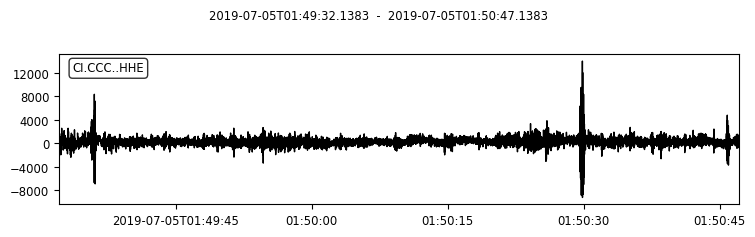

In [37]:
st = obspy.read("/Volumes/LaCie/data/ridgecrest2019/RC_M1.0to1.2/37240892/CCC.CI.HHE..2019.186.014947.37240892.ms")
tr = st[0]
tr.plot()
data_obspy = tr.data

In [8]:
len(data_mseed), len(data_obspy)

(7501, 7501)

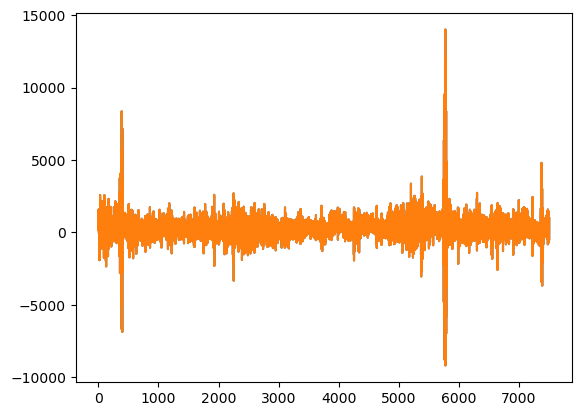

In [12]:
plt.figure()
plt.plot(data_mseed)
plt.plot(data_obspy)
plt.show()

In [14]:
all(data_mseed==data_obspy)

True

In [ ]:
data_obspy

In [ ]:
data_mseed

In [ ]:
tr.stats

In [ ]:
traceid.segments()

In [ ]:
segment.datasamples[:3]

In [ ]:
dir(segment)